# PPA Assessment for Task 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
DIR_REPORT = "../../SiLagoNN/syn/rpt/flat_sweep/"
DIR_LOG = "../../SiLagoNN/exe/log/task2/"
# print(os.listdir(DIR_LOG))
LOG_ID = '@[IL2225-Project]'

## Frequency X compilation time

In [3]:
with open(DIR_LOG+'console_task2_sweep_1.log', 'r') as f:
    lines = f.readlines()
    filtered = np.array([line.replace(LOG_ID+' ','').strip() for line in lines if line.startswith(LOG_ID)])
    filtered = np.array([int(line.split(' : ')[1][11:].split(' [')[0]) 
                         for line in filtered if line.startswith('Constraint ')])
    period   = filtered[::2]
    exe_time = filtered[1::2] #[min]


with open(DIR_LOG+'console_task2_sweep_2.log', 'r') as f:
    lines = f.readlines()
    filtered = np.array([line.replace(LOG_ID+' ','').strip() for line in lines if line.startswith(LOG_ID)])
    filtered = np.array([int(line.split(' : ')[1][11:].split(' [')[0]) 
                         for line in filtered if line.startswith('Constraint ')])
    period = np.append(period, filtered[::2])
    exe_time = np.append(exe_time, filtered[1::2])


with open(DIR_LOG+'console_task2_sweep_3.log', 'r') as f:
    lines = f.readlines()
    filtered = np.array([line.replace(LOG_ID+' ','').strip() for line in lines if line.startswith(LOG_ID)])
    filtered = np.array([int(line.split(' : ')[1][11:].split(' [')[0]) 
                         for line in filtered if line.startswith('Constraint ')])
    period = np.append(period, filtered[::2][:-1])
    exe_time = np.append(exe_time, filtered[1::2])

with open(DIR_LOG+'console_task2_sweep_4.log', 'r') as f:
    lines = f.readlines()
    filtered = np.array([line.replace(LOG_ID+' ','').strip() for line in lines if line.startswith(LOG_ID)])
    filtered = np.array([int(line.split(' : ')[1][11:].split(' [')[0]) 
                         for line in filtered if line.startswith('Constraint ')])
    period = np.append(period, filtered[0])
    temp = period[-2]
    period[-2] = period[-1]
    period[-1] = temp
    freq     = 1e-6/(period*1e-12) #[MHz]
    exe_time = np.append(exe_time, filtered[1])
    temp = exe_time[-2]
    exe_time[-2] = exe_time[-1]
    exe_time[-1] = temp

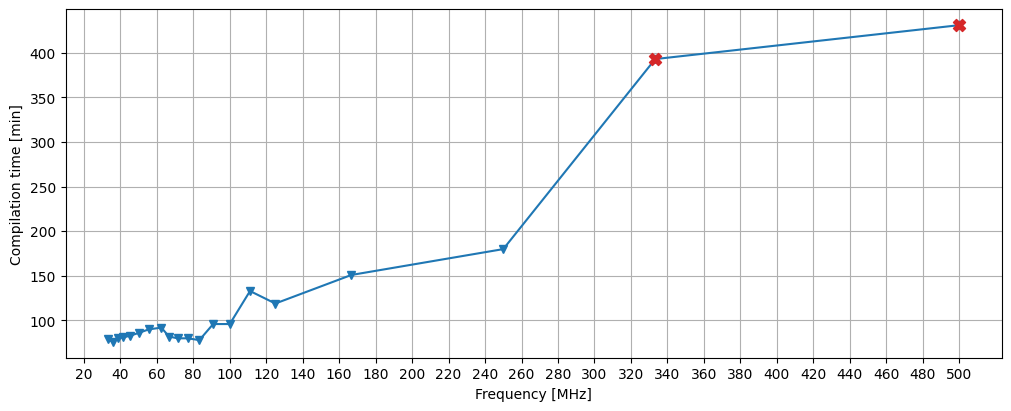

In [4]:
plt.figure(figsize=(10,4), layout='constrained')
plt.plot(freq,exe_time,'v-')
plt.scatter(freq[-2:],exe_time[-2:], marker='X', color='tab:red', s=75, zorder=10)
plt.grid()
plt.xlabel("Frequency [MHz]"); plt.ylabel("Compilation time [min]")
# plt.xticks(freq,rotation=45)
plt.xticks(np.arange(20,500+20,20))
plt.savefig('compile_time.pdf'); plt.show()

## Frequency X Power

In [5]:
power_repartition = {}
for i,T in enumerate(period):
    df = pd.DataFrame([], columns=['Internal Power (mW)', 'Switching Power (mW)', 'Leakage Power (µW)', 'Total Power (mW)', 'Total Power (%)'])
    with open(DIR_REPORT+f'drra_wrapper_power_{T}.txt') as f:
        lines = f.readlines()
        df.loc['clock_network'] = np.array(
            [line.replace('clock_network ','').replace('(','').replace(')','').replace('i','').replace('%','').strip().split() 
             for line in lines if line.startswith('clock_network')], dtype=float)[0]
        df.loc['register'] = np.array(
            [line.replace('register ','').replace('(','').replace(')','').replace('i','').replace('%','').strip().split() 
             for line in lines if line.startswith('register')], dtype=float)[0]
        df.loc['combinational'] = np.array(
            [line.replace('combinational ','').replace('(','').replace(')','').replace('i','').replace('%','').strip().split() 
             for line in lines if line.startswith('combinational')], dtype=float)[0]
        tot = [line.replace('Total','').replace('mW','').replace('uW','').strip().split()
             for line in lines if line.startswith('Total  ')][0]; tot.append(100);
        df.loc['Total']=np.array(tot,dtype=float)
    power_repartition[T] = df

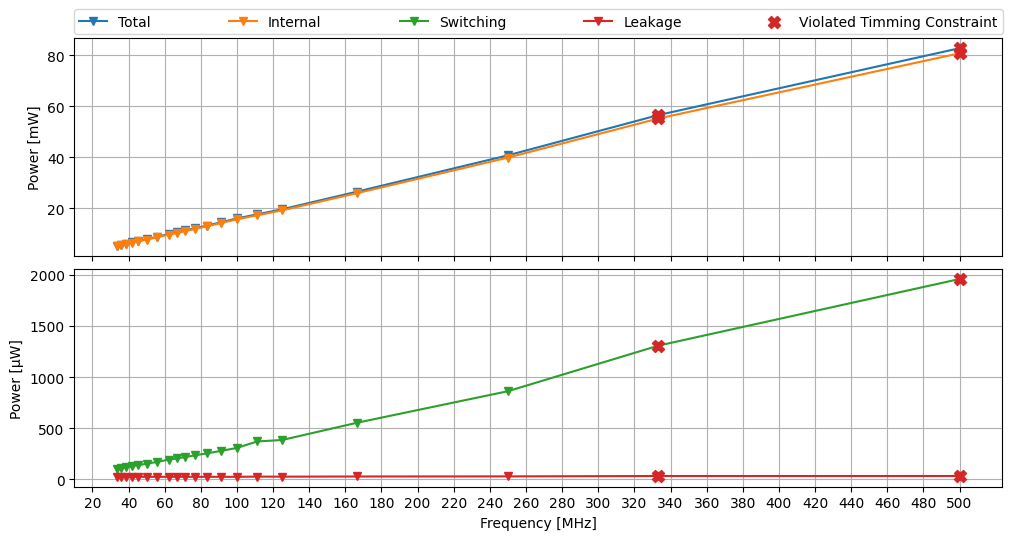

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(10,5), sharex=True, layout='constrained')

axs[0].plot(
    freq,
    np.array([df.loc['Total', 'Total Power (mW)'] for T, df in power_repartition.items()]), 
    'v-',
    label='Total'
)
axs[0].plot(
    freq,
    np.array([df.loc['Total', 'Internal Power (mW)'] for T, df in power_repartition.items()]), 
    'v-',
    label='Internal'
)
axs[0].scatter(
    [freq[-1],freq[-2]]*2,
    [power_repartition[period[-1]].loc['Total', 'Internal Power (mW)'],
     power_repartition[period[-2]].loc['Total', 'Internal Power (mW)'],
     power_repartition[period[-1]].loc['Total', 'Total Power (mW)'],
     power_repartition[period[-2]].loc['Total', 'Total Power (mW)']], 
    marker='X', color='tab:red', s=75, zorder=10)


axs[1].plot(
    freq,
    np.array([df.loc['Total', 'Switching Power (mW)'] for T, df in power_repartition.items()])*1000, 
    'v-',
    label='Switching',
    color='tab:green'
)
axs[1].plot(
    freq,
    np.array([df.loc['Total', 'Leakage Power (µW)'] for T, df in power_repartition.items()]), 
    'v-',
    label='Leakage',
    color='tab:red'
)
axs[1].scatter(
    [freq[-1],freq[-2]]*2,
    [power_repartition[period[-1]].loc['Total', 'Switching Power (mW)']*1000,
     power_repartition[period[-2]].loc['Total', 'Switching Power (mW)']*1000,
     power_repartition[period[-1]].loc['Total', 'Leakage Power (µW)'],
     power_repartition[period[-2]].loc['Total', 'Leakage Power (µW)']], 
    marker='X', color='tab:red', s=75, zorder=10, label='Violated Timming Constraint')


axs[0].grid(); axs[1].grid()
axs[1].set_xlabel("Frequency [MHz]"); axs[0].set_ylabel("Power [mW]"); axs[1].set_ylabel("Power [µW]")
# axs[1].set_xticks(freq); axs[1].xaxis.set_tick_params(rotation=45)
axs[1].set_xticks(np.arange(20,500+20,20))
fig.legend(bbox_to_anchor=(0.068, 1., 0.929, .102), loc='lower left', ncols=5, mode="expand", borderaxespad=0.)
plt.savefig('power.pdf', bbox_inches='tight'); plt.show()

## Frequency X Area

In [7]:
area = pd.DataFrame([], columns=['Combinational area', 'Buf/Inv area', 'Noncombinational area', 'Total cell area'])
for i,T in enumerate(period):
    with open(DIR_REPORT+f'drra_wrapper_area_{T}.txt') as f:
        lines = f.readlines()
        area.loc[T,'Combinational area'] = np.array(
            [line.strip().split()[2]
             for line in lines if line.startswith('Combinational area')], dtype=float)[0]
        area.loc[T,'Buf/Inv area'] = np.array(
            [line.strip().split()[2]
             for line in lines if line.startswith('Buf/Inv area')], dtype=float)[0]
        area.loc[T,'Noncombinational area'] = np.array(
            [line.strip().split()[2]
             for line in lines if line.startswith('Noncombinational area')], dtype=float)[0]
        area.loc[T,'Total cell area'] = np.array(
            [line.strip().split()[3]
             for line in lines if line.startswith('Total cell area')], dtype=float)[0]

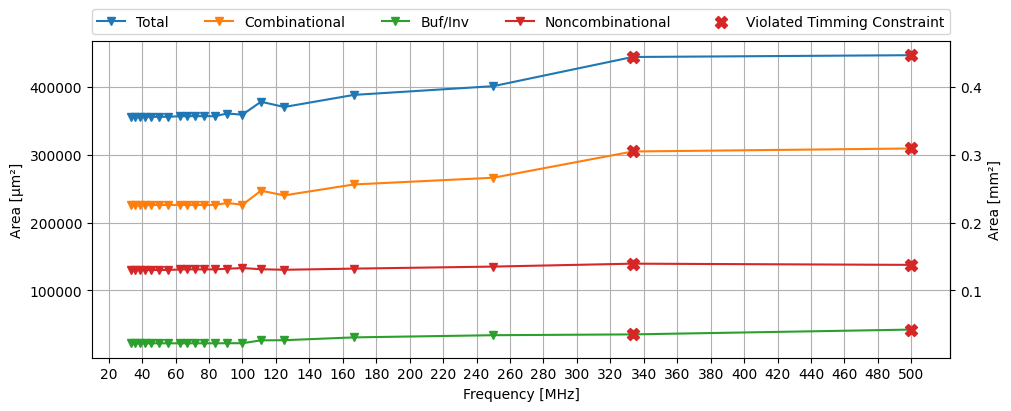

In [8]:
fig, ax = plt.subplots(figsize=(10,4), layout='constrained')

ax.plot(freq, area['Total cell area']      ,'v-',label='Total')
ax.plot(freq, area['Combinational area']   ,'v-',label='Combinational')
ax.plot(freq, area['Buf/Inv area']         ,'v-',label='Buf/Inv')
ax.plot(freq, area['Noncombinational area'],'v-',label='Noncombinational')

ax.scatter([freq[-1]]*4, [*area.loc[period[-1]]], 
           marker='X', color='tab:red', s=75, zorder=10, label='Violated Timming Constraint')
ax.scatter([freq[-2]]*4, [*area.loc[period[-2]]], 
           marker='X', color='tab:red', s=75, zorder=10)


ax.grid()
ax.set_xlabel("Frequency [MHz]"); ax.set_ylabel("Area [µm²]")
# plt.xticks(freq,rotation=45)
ax.set_xticks(np.arange(20,500+20,20))
ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncols=5, mode="expand", borderaxespad=0.)


def µm2_to_mm2(x):
    return x*1e-6

def mm2_to_µm2(x):
    return x*1e6

secax_y = ax.secondary_yaxis(
    'right', functions=(µm2_to_mm2, mm2_to_µm2))
secax_y.set_ylabel('Area [mm²]')

plt.savefig('area.pdf'); plt.show()